In [1]:
import pandas as pd
import numpy as np
import os
import glob

SELECTED_FEATURES = [
    'IAT', 'syn_flag_number', 'psh_flag_number', 'fin_flag_number', 
    'rst_flag_number', 'ack_flag_number', 'Tot sum', 'Protocol Type', 
    'flow_duration', 'Rate', 'Std', 'Variance', 'UDP', 'TCP', 'HTTP', 
    'HTTPS', 'DNS', 'Duration', 'Number', 'ICMP', 'Magnitue', 
    'Header_Length', 'AVG', 'Min', 'Max'
]

INPUT_DIR         = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/'
LABEL_MAP_PATH    = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
OUTPUT_DATA       = '/kaggle/working/RECON_research_data_V7_Elite.csv.gz'
SAMPLES_PER_LABEL = 100_000

recon_mapping_logic = {
    'Recon-PingSweep':     'Recon-PingSweep',
    'Recon-OSScan':        'Recon-OSScan',
    'VulnerabilityScan':   'VulnerabilityScan',
    'Recon-PortScan':      'Recon-PortScan',
    'Recon-HostDiscovery': 'Recon-HostDiscovery'
}

def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

def process_recon_data():
    label_lookup = pd.read_csv(LABEL_MAP_PATH)
    first_write  = True

    csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
    print(f"Bắt đầu trích xuất chuyên sâu RECON (5 nhãn) trên {len(csv_files)} file...")

    # Dùng .values() vì target_name là tên ngắn (giá trị của dict)
    stats = {name: 0 for name in recon_mapping_logic.values()}

    for file_path in csv_files:
        temp_df = pd.read_csv(file_path, nrows=1)
        if 'label' not in temp_df.columns: continue
        label_id = temp_df['label'].iloc[0]

        match = label_lookup[label_lookup['Encoded_ID'] == label_id]
        if match.empty: continue
        original_name = match['Original_Label'].values[0]

        if original_name not in recon_mapping_logic:
            continue

        target_name = recon_mapping_logic[original_name]

        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in SELECTED_FEATURES if c in available_cols]
        df_full = pd.read_csv(file_path, usecols=use_cols)

        df_cleaned = basic_clean(df_full)
        if len(df_cleaned) == 0: continue

        num_sample = min(len(df_cleaned), SAMPLES_PER_LABEL)
        df_sampled = df_cleaned.sample(n=num_sample, random_state=42)

        df_sampled['layer2_label'] = target_name
        stats[target_name] += num_sample

        if first_write:
            df_sampled.to_csv(OUTPUT_DATA, index=False, compression='gzip')
            first_write = False
        else:
            df_sampled.to_csv(OUTPUT_DATA, mode='a', index=False, header=False, compression='gzip')

        print(f"Đã trích xuất: {original_name} -> {target_name} ({num_sample:,} dòng)")
        del df_full, df_cleaned, df_sampled

    print("\n" + "="*50)
    print("TỔNG KẾT DỮ LIỆU RECON:")
    for name, count in stats.items():
        print(f"  - {name:25}: {count:,} dòng")
    print(f"File lưu tại: {OUTPUT_DATA}")
    print("="*50)

if __name__ == "__main__":
    process_recon_data()


Bắt đầu trích xuất chuyên sâu RECON (5 nhãn) trên 34 file...
Đã trích xuất: Recon-HostDiscovery -> Recon-HostDiscovery (100,000 dòng)
Đã trích xuất: VulnerabilityScan -> VulnerabilityScan (37,382 dòng)
Đã trích xuất: Recon-PortScan -> Recon-PortScan (82,284 dòng)
Đã trích xuất: Recon-OSScan -> Recon-OSScan (98,259 dòng)
Đã trích xuất: Recon-PingSweep -> Recon-PingSweep (2,262 dòng)

TỔNG KẾT DỮ LIỆU RECON:
  - Recon-PingSweep          : 2,262 dòng
  - Recon-OSScan             : 98,259 dòng
  - VulnerabilityScan        : 37,382 dòng
  - Recon-PortScan           : 82,284 dòng
  - Recon-HostDiscovery      : 100,000 dòng
File lưu tại: /kaggle/working/RECON_research_data_V7_Elite.csv.gz


=> Đang tải dữ liệu RECON (5 nhãn chi tiết)...
Các nhóm RECON nhận diện: ['Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'VulnerabilityScan']

=> Bắt đầu huấn luyện và đánh giá 5-Fold CV cho họ RECON...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[601]	valid_0's multi_logloss: 0.271187
   + Hoàn thành Fold 1 | F1: 0.8564
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[714]	valid_0's multi_logloss: 0.269018
   + Hoàn thành Fold 2 | F1: 0.8634
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[620]	valid_0's multi_logloss: 0.270033
   + Hoàn thành Fold 3 | F1: 0.8601
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[614]	valid_0's multi_logloss: 0.274105
   + Hoàn thành Fold 4 | F1: 0.8597
Training until validation scores don't improve for 100 rounds
Early stopping

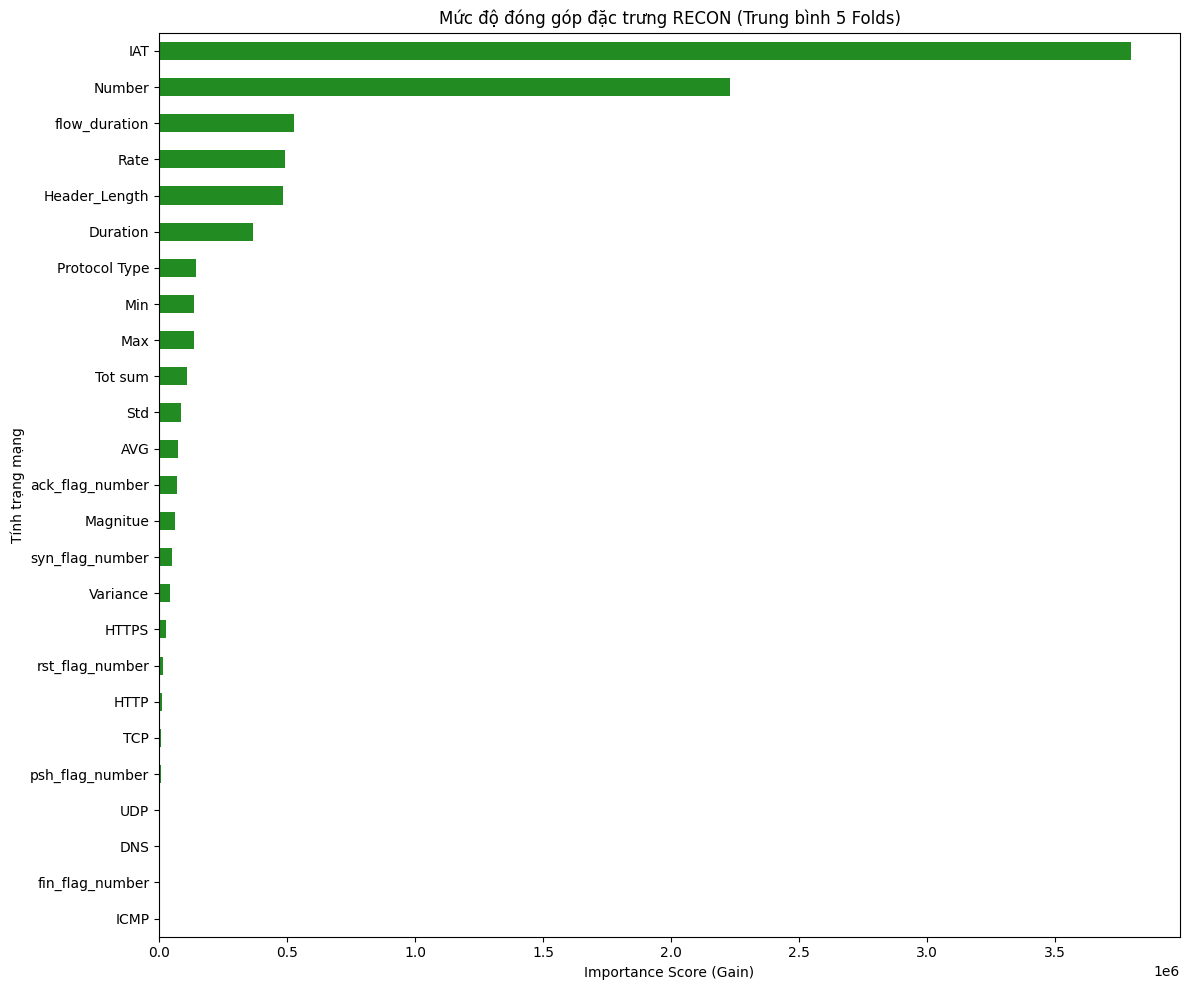

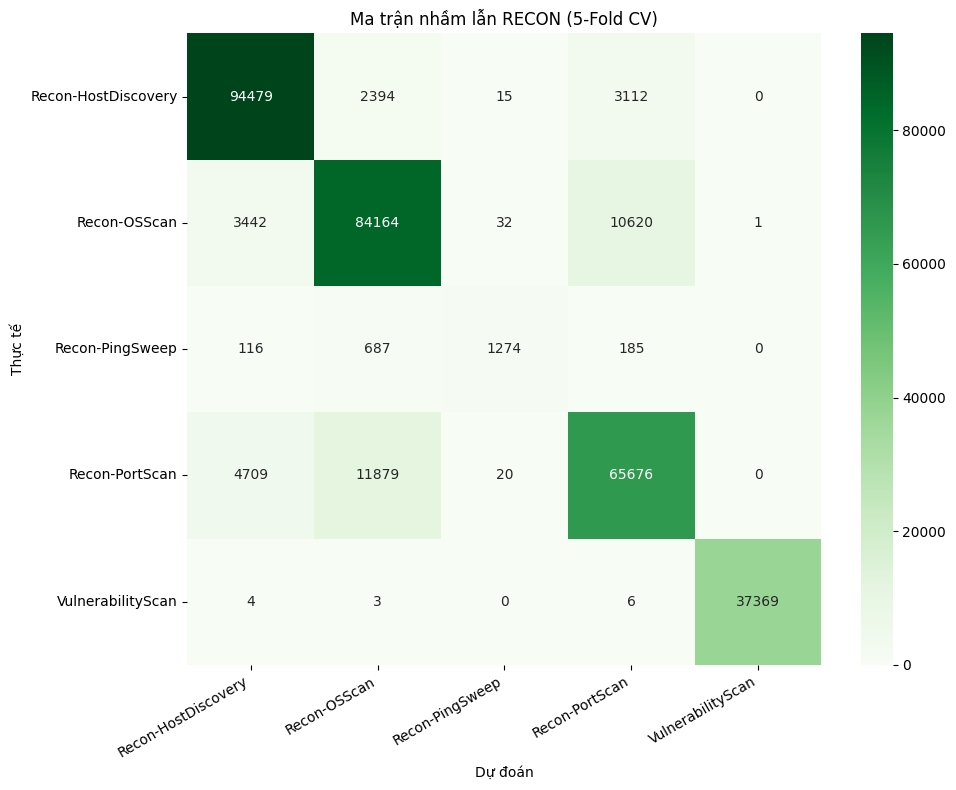

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# --- 1. CẤU HÌNH ---
INPUT_FILE     = '/kaggle/working/RECON_research_data_V7_Elite.csv.gz'
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
K_FOLDS        = 5

print("=> Đang tải dữ liệu RECON (5 nhãn chi tiết)...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# --- Nạp bảng ánh xạ nhãn thật ---
label_lookup = pd.read_csv(LABEL_MAP_PATH)
id_to_name   = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

# Tên hiển thị ngắn gọn cho RECON
short_name_map = {
    'Recon-PingSweep':     'PingSweep',
    'Recon-OSScan':        'OSScan',
    'VulnerabilityScan':   'VulnerabilityScan',
    'Recon-PortScan':      'PortScan',
    'Recon-HostDiscovery': 'HostDiscovery'
}

target_col = 'layer2_label' if 'layer2_label' in df.columns else df.columns[-1]
X          = df.drop(columns=[target_col])

# Bước 1: ID số -> tên gốc, Bước 2: tên gốc -> tên ngắn
y_raw = (df[target_col]
         .map(id_to_name)
         .map(short_name_map)
         .fillna(df[target_col].astype(str)))

le           = LabelEncoder()
y            = pd.Series(le.fit_transform(y_raw))
target_names = le.classes_
print(f"Các nhóm RECON nhận diện: {list(target_names)}")

# --- 2. THIẾT LẬP K-FOLD ---
skf                   = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_metrics          = []
all_latency           = []
oof_preds             = np.zeros(len(df))
feature_importance_df = pd.DataFrame()

print(f"\n=> Bắt đầu huấn luyện và đánh giá {K_FOLDS}-Fold CV cho họ RECON...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    params = {
        'objective':        'multiclass',
        'num_class':        len(target_names),
        'metric':           'multi_logloss',
        'is_unbalance':     True,
        'learning_rate':    0.03,
        'num_leaves':       127,
        'max_bin':          511,
        'min_data_in_leaf': 20,
        'feature_fraction': 0.85,
        'bagging_fraction': 0.85,
        'bagging_freq':     5,
        'lambda_l1':        0.05,
        'lambda_l2':        0.10,
        'device':           'cpu',
        'verbose':          -1,
        'seed':             42
    }

    train_set = lgb.Dataset(X_train, label=y_train)
    val_set   = lgb.Dataset(X_val,   label=y_val, reference=train_set)

    model = lgb.train(
        params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=3000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=0)
        ]
    )

    start_pred = time.time()
    y_prob     = model.predict(X_val)
    end_pred   = time.time()

    y_pred             = np.argmax(y_prob, axis=1)
    oof_preds[val_idx] = y_pred

    all_latency.append((end_pred - start_pred) / len(X_val))

    fold_imp = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': model.feature_importance(importance_type='gain')
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)

    fold_metrics.append({
        'accuracy':  accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_val, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_val, y_pred, average='macro', zero_division=0)
    })
    print(f"   + Hoàn thành Fold {fold+1} | F1: {fold_metrics[-1]['f1']:.4f}")

# --- 3. TỔNG HỢP KẾT QUẢ ---
metrics_df     = pd.DataFrame(fold_metrics)
avg_metrics    = metrics_df.mean()
std_metrics    = metrics_df.std()
avg_latency_ms = np.mean(all_latency) * 1000

print("\n" + "="*50)
print(f"⭐ KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ({K_FOLDS}-FOLD) - HỌ RECON")
print("-" * 50)
print(f"1. Accuracy:  {avg_metrics['accuracy']:.4f} (±{std_metrics['accuracy']:.4f})")
print(f"2. Precision: {avg_metrics['precision']:.4f} (±{std_metrics['precision']:.4f})")
print(f"3. Recall:    {avg_metrics['recall']:.4f} (±{std_metrics['recall']:.4f})")
print(f"4. F1-Score:  {avg_metrics['f1']:.4f} (±{std_metrics['f1']:.4f})")
print("-" * 50)
print(f"⏱ Tốc độ dự đoán trung bình: {avg_latency_ms:.6f} ms/dòng")

if avg_metrics['f1'] >= 0.90:
    print("✅ ĐẠT MỤC TIÊU F1 > 90%")
else:
    print(f"⚠️  Chưa đạt mục tiêu — F1 hiện tại: {avg_metrics['f1']:.4f}")
print("="*50)

print("\nBáo cáo phân loại chi tiết (Out-of-Fold):")
print(classification_report(y, oof_preds, target_names=target_names, zero_division=0))

# --- 4. BIỂU ĐỒ ĐẶC TRƯNG ---
plt.figure(figsize=(12, 10))
mean_imp = (feature_importance_df.groupby('Feature')['Importance']
                                 .mean()
                                 .sort_values(ascending=True))
mean_imp.plot(kind='barh', color='forestgreen')
plt.title(f'Mức độ đóng góp đặc trưng RECON (Trung bình {K_FOLDS} Folds)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Tính trạng mạng')
plt.tight_layout()
plt.savefig('/kaggle/working/recon_feature_importance.png')
plt.show()

# --- 5. MA TRẬN NHẦM LẪN ---
cm = confusion_matrix(y, oof_preds)
fig_h = max(8, len(target_names) * 1.5)
plt.figure(figsize=(fig_h + 2, fig_h))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Ma trận nhầm lẫn RECON ({K_FOLDS}-Fold CV)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/recon_confusion_matrix.png')
plt.show()


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from sklearn.preprocessing import LabelEncoder

# --- 1. CẤU HÌNH ĐẦU VÀO & ĐẦU RA ---
INPUT_FILE         = '/kaggle/working/RECON_research_data_V7_Elite.csv.gz'
MODEL_SAVE_PATH    = '/kaggle/working/lightgbm_recon_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/recon_encoder.pkl'
META_DATA_PATH     = '/kaggle/working/recon_meta.pkl'

print("=> Đang tải dữ liệu RECON để huấn luyện...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# --- 2. TÁCH X VÀ y ---
X     = df.drop(columns=['layer2_label'])
y_raw = df['layer2_label']

# --- 3. MÃ HÓA NHÃN VÀ LƯU ENCODER ---
print("=> Đang mã hóa nhãn và lưu LabelEncoder...")
le = LabelEncoder()
y  = le.fit_transform(y_raw)

with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)
print(f"   + Đã nhận diện các lớp: {list(le.classes_)}")

# --- 4. THIẾT LẬP THAM SỐ ---
params = {
    'objective':        'multiclass',
    'num_class':        len(np.unique(y)),
    'metric':           'multi_logloss',
    'is_unbalance':     True,
    'learning_rate':    0.015,
    'num_leaves':       255,
    'max_bin':          511,
    'device':           'cpu',
    'verbose':          -1,
    'seed':             42
}

# --- 5. HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ---
print(f"\n=> Đang huấn luyện mô hình RECON trên toàn bộ {len(df):,} dòng dữ liệu...")
start_time = time.time()

train_set   = lgb.Dataset(X, label=y)
final_model = lgb.train(params, train_set, num_boost_round=2000)

training_duration = time.time() - start_time
print(f"\n=> Huấn luyện hoàn tất trong {training_duration:.2f} giây.")

# --- 6. LƯU MÔ HÌNH VÀ SIÊU DỮ LIỆU ---
final_model.save_model(MODEL_SAVE_PATH)
print(f"   [+] Đã lưu mô hình tại: {MODEL_SAVE_PATH}")

model_info = {
    'features':  list(X.columns),
    'num_class': params['num_class']
}
with open(META_DATA_PATH, 'wb') as f:
    pickle.dump(model_info, f)
print(f"   [+] Đã lưu meta tại   : {META_DATA_PATH}")
print(f"   [+] Đã lưu encoder tại: {LABEL_ENCODER_PATH}")

print("\n=> HỆ THỐNG RECON (5 NHÃN) ĐÃ SẴN SÀNG!")


=> Đang tải dữ liệu RECON để huấn luyện...
=> Đang mã hóa nhãn và lưu LabelEncoder...
   + Đã nhận diện các lớp: ['Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'VulnerabilityScan']

=> Đang huấn luyện mô hình RECON trên toàn bộ 320,187 dòng dữ liệu...

=> Huấn luyện hoàn tất trong 403.56 giây.
   [+] Đã lưu mô hình tại: /kaggle/working/lightgbm_recon_model.txt
   [+] Đã lưu meta tại   : /kaggle/working/recon_meta.pkl
   [+] Đã lưu encoder tại: /kaggle/working/recon_encoder.pkl

=> HỆ THỐNG RECON (5 NHÃN) ĐÃ SẴN SÀNG!


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import os
import glob
import random

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
MODEL_PATH         = '/kaggle/working/lightgbm_recon_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/recon_encoder.pkl'
META_DATA_PATH     = '/kaggle/working/recon_meta.pkl'

INPUT_DIR      = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/'
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'

# Mapping nhãn gốc -> tên ngắn (khớp với lúc trích xuất)
recon_mapping_logic = {
    'Recon-PingSweep':     'Recon-PingSweep',
    'Recon-OSScan':        'Recon-OSScan',
    'VulnerabilityScan':   'VulnerabilityScan',
    'Recon-PortScan':      'Recon-PortScan',
    'Recon-HostDiscovery': 'Recon-HostDiscovery'
}

TARGET_RECON_LABELS = list(recon_mapping_logic.keys())

print("=> Đang khởi động hệ thống AI RECON (5 nhãn)...")
model = lgb.Booster(model_file=MODEL_PATH)
with open(LABEL_ENCODER_PATH, 'rb') as f: le = pickle.load(f)
with open(META_DATA_PATH,     'rb') as f: expected_features = pickle.load(f)['features']

# ==========================================
# 2. SINH TRỌNG SỐ ĐẶC TRƯNG
# ==========================================
print("\n" + "="*55)
print("⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (RECON 5 NHÃN)")
print("="*55)

weights   = model.feature_importance(importance_type='gain')
weight_df = pd.DataFrame({
    'Feature':      expected_features,
    'Weight (Gain)': weights
})
weight_df = weight_df.sort_values(by='Weight (Gain)', ascending=False)
weight_df['Contribution (%)'] = (weight_df['Weight (Gain)'] / weight_df['Weight (Gain)'].sum()) * 100

print(weight_df.head(10).to_string(index=False))
weight_df.to_csv('/kaggle/working/recon_feature_weights.txt', index=False,sep='\t')
print("\n[+] Đã lưu trọng số tại: recon_feature_weights.txt")

# ==========================================
# 3. THUẬT TOÁN GOM RỔ DỮ LIỆU ĐẢM BẢO ĐỦ 10 MẪU
# ==========================================
print("\n" + "="*60)
print("🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC")
print("="*60)

csv_files    = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
label_lookup = pd.read_csv(LABEL_MAP_PATH)
label_dict   = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

random.shuffle(csv_files)
sample_pool      = []
target_count     = 10
samples_per_file = 4

print("=> Đang rải lưới quét dữ liệu RECON...")

for file_path in csv_files:
    temp_df = pd.read_csv(file_path, nrows=1)
    if 'label' not in temp_df.columns: continue

    label_id      = temp_df['label'].iloc[0]
    original_name = label_dict.get(label_id, "")

    if original_name not in TARGET_RECON_LABELS:
        continue

    available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
    use_cols       = [c for c in expected_features if c in available_cols]

    df_raw     = pd.read_csv(file_path, usecols=use_cols)
    df_cleaned = df_raw.replace([np.inf, -np.inf], np.nan).dropna()

    if len(df_cleaned) > 0:
        take_n     = min(len(df_cleaned), samples_per_file)
        df_sampled = df_cleaned.sample(n=take_n)
        df_sampled['True_Answer'] = recon_mapping_logic[original_name]  # tên ngắn
        sample_pool.append(df_sampled)

    if sum(len(d) for d in sample_pool) >= target_count * 2:
        break

# ==========================================
# 4. CHỐT SỔ VÀ DỰ ĐOÁN
# ==========================================
if not sample_pool:
    print("⚠️ Không tìm thấy mẫu RECON nào.")
else:
    master_df = pd.concat(sample_pool, ignore_index=True)

    if len(master_df) >= target_count:
        test_df = master_df.sample(n=target_count).reset_index(drop=True)
    else:
        test_df = master_df.sample(frac=1.0).reset_index(drop=True)

    true_labels = test_df['True_Answer'].tolist()
    X_test      = test_df[expected_features]
    X_test      = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

    y_prob          = model.predict(X_test)
    y_pred_indices  = np.argmax(y_prob, axis=1)
    confidences     = np.max(y_prob, axis=1) * 100
    y_pred_names    = le.inverse_transform(y_pred_indices)

    correct_count = 0
    for i in range(len(test_df)):
        is_correct = (true_labels[i] == y_pred_names[i])
        if is_correct: correct_count += 1

        print(f"STT {i+1}:")
        print(f"   - Thực tế: {true_labels[i]}")
        print(f"   - AI đoán: {y_pred_names[i]} (Độ tự tin: {confidences[i]:.2f}%)")
        print(f"   => {'✅ CHÍNH XÁC' if is_correct else '❌ SAI LỆCH'}")
        print("-" * 45)

    print(f"🏆 TỔNG KẾT: Đúng {correct_count}/{len(test_df)} mẫu.")


=> Đang khởi động hệ thống AI RECON (5 nhãn)...

⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (RECON 5 NHÃN)
      Feature  Weight (Gain)  Contribution (%)
          IAT   1.099552e+07         40.713851
       Number   7.122646e+06         26.373511
         Rate   1.592259e+06          5.895768
Header_Length   1.574017e+06          5.828219
flow_duration   1.510185e+06          5.591865
     Duration   1.110644e+06          4.112459
Protocol Type   5.410334e+05          2.003322
          Min   5.026569e+05          1.861222
      Tot sum   3.792441e+05          1.404253
          Max   3.628344e+05          1.343492

[+] Đã lưu trọng số tại: recon_feature_weights.txt

🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC
=> Đang rải lưới quét dữ liệu RECON...
STT 1:
   - Thực tế: VulnerabilityScan
   - AI đoán: VulnerabilityScan (Độ tự tin: 100.00%)
   => ✅ CHÍNH XÁC
---------------------------------------------
STT 2:
   - Thực tế: Recon-OSScan
   - AI đoán: Recon-OSScan (Độ tự tin: 87.11